Name :- Sarthak Zunjure

Roll no :- 03

*PRN* no :- 1252090003

11. Assignment on Classification technique. Every year many students give the GRE exam to get admission in foreign Universities. The data set contains GRE Scores (out of 340), TOEFL Scores (out of 120), University Rating (out of 5), Statement of Purpose strength (out of 5), Letter of Recommendation strength (out of 5), Undergraduate GPA (out of 10), Research Experience (0=no, 1=yes), Admitted (0=no, 1=yes). Admitted is the target variable.

Data Set: https://www.kaggle.com/mohansacharya/graduate-admissions

The counsellor of the firm is supposed check whether the student will get an admission or not based on his/her GRE score and Academic Score. So to help the counsellor to make appropriate decisions, build a machine learning model classifier using a Decision tree to predict whether a student will get admission or not.  Apply Data pre-processing (Label Encoding, Data Transformation….) techniques if necessary.

Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.

Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Step 2: Load Dataset

In [ ]:
df = pd.read_csv("Admission_Predict_Ver1.1.csv")
print(df.head())

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  


Step 3: Data Preprocessing

1. Drop unnecessary column

In [ ]:
df.drop("Serial No.", axis=1, inplace=True)

2. Convert target into classification

Dataset has Chance of Admit (0–1) → convert to binary:

In [ ]:
df['Admitted'] = df['Chance of Admit '] >= 0.75
df['Admitted'] = df['Admitted'].astype(int)

3. Drop original target

In [ ]:
df.drop("Chance of Admit ", axis=1, inplace=True)

Step 4: Define Features & Target

In [ ]:
X = df.drop("Admitted", axis=1)
y = df["Admitted"]

Step 5: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Step 6: Apply Decision Tree Classifier

In [ ]:
model = DecisionTreeClassifier(criterion='gini', max_depth=4)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

Step 7: Predictions

In [ ]:
y_pred = model.predict(X_test)

Step 8: Model Evaluation

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.87
Confusion Matrix:
 [[54 10]
 [ 3 33]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.84      0.89        64
           1       0.77      0.92      0.84        36

    accuracy                           0.87       100
   macro avg       0.86      0.88      0.86       100
weighted avg       0.88      0.87      0.87       100



Step 9: Test with Custom Input

In [ ]:
# Example student data
sample = [[320, 110, 4, 4.5, 4, 9, 1]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Student will get admission")
else:
    print("Student will NOT get admission")

Student will get admission


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Step 10: Visualization (Decision Tree)

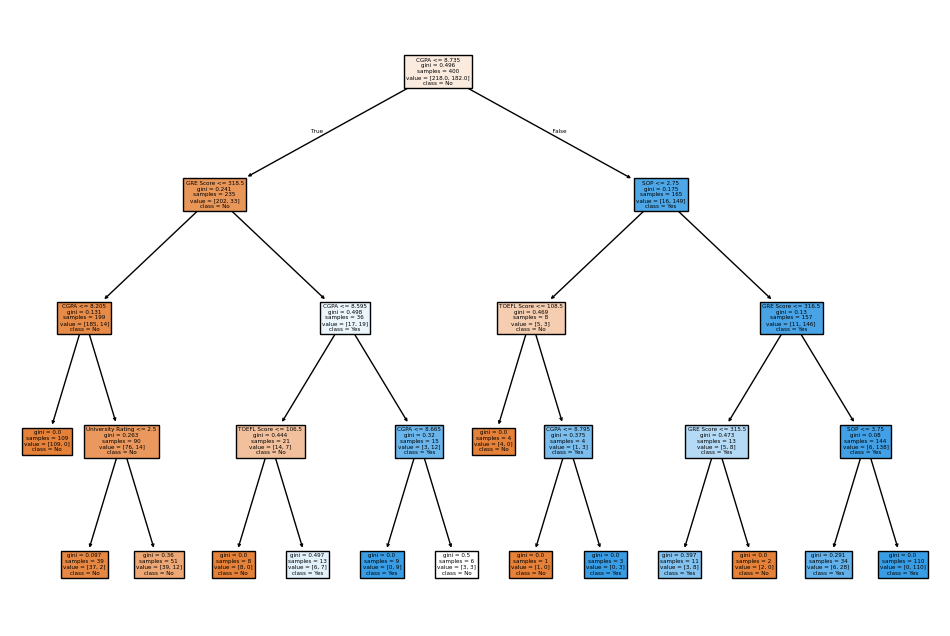

In [ ]:
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=X.columns, class_names=["No", "Yes"], filled=True)
plt.show()